# Statistics - 3 (Sampling)

- Sampling is the process of selecting a subset of data (sample) from a larger population so that we can analyze it and make conclusions about the whole
-Why we sample:
Saves time and cost
Easier to collect and process
Useful when population data is too large or infinite


## Simple Random Sampling

In [3]:
import random

In [4]:
population = list(range(1,101))
print(population)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


In [8]:
sample = random.sample(population, 10)
print(sample)

[65, 11, 24, 72, 52, 32, 7, 80, 77, 31]


In [12]:
import numpy as np

population1 = np.arange(1,101)
print(population1)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]


In [15]:
data = np.random.choice(population1, size = 10, replace=False) #replace=False → sampling without replacement
data                                                           # replace=True → sampling with replacement /no. can be repeated 

array([ 61,  14,  22, 100,  18,  44,  59,  56,  76,  37])

## Categories

- categories: This list contains the distinct categorical values you want to sample from.

In [22]:
import numpy as np
# Define the categorical values (e.g., 'A', 'B', 'C')
categories = ['A', 'B' , 'C']

In [21]:
# Define the desired proportions for each category, # These proportions must sum to 1
proportions = [0.2, 0.3, 0.5]

In [23]:
# Define the number of samples to generate
num_samples = 10

In [25]:
# Generate the samples
sample_data = np.random.choice(categories, size =num_samples, p = proportions) # <U1 = Each element is a Unicode string containing 1 character."
sample_data

array(['C', 'A', 'B', 'C', 'C', 'A', 'B', 'B', 'B', 'A'], dtype='<U1')

In [29]:
# You can then verify the proportions in your sampled data; # For example, count the occurrences of each category
from collections import Counter
counts = Counter (sample_data)
print(f"Sample Counts: {counts}")

Sample Counts: Counter({'B': 4, 'C': 3, 'A': 3})


In [32]:
# And calculate the observed proportions
# observed proportions calculates how much each category represents out of the total and stores those percentages
#count / num_samples
# → divides each category’s count by the total number of samples.
# → This gives you the proportion (percentage) of each category.

num_samples1 = 20
observed_proportions = {cat: count / num_samples1 for cat, count in counts.items()} 
print(f"Observed proportions: {observed_proportions}")

Observed proportions: {'C': 0.15, 'A': 0.15, 'B': 0.2}


In [39]:
num_samples = 10
observed_proportions1 = {apple:count / num_samples for apple, count in counts.items()}
observed_proportions1

{'C': 0.3, 'A': 0.3, 'B': 0.4}

In [51]:
import pandas as pd

df = pd.DataFrame({
    'id': range(1, 101),
    'age': np.random.randint(50, 60, 100) #50-60 age group of 100 id
})
df

,id,age
0,1,56
1,2,53
2,3,53
3,4,51
4,5,50
...,...,...
95,96,50
96,97,54
97,98,59
98,99,50


## 1.Simple random sample of 5 rows

In [55]:
sample_df = df.sample(n= 5, random_state = 25)
sample_df

,id,age
41,42,51
29,30,59
33,34,54
65,66,57
74,75,51


## 2.Stratified Sampling (by group)

In [58]:
# Sample 30% from each group
stratified_sample = df.groupby('age').sample(frac = 0.30, random_state = 1)
stratified_sample

,id,age
22,23,50
91,92,50
35,36,50
13,14,50
32,33,50
53,54,51
30,31,51
75,76,51
58,59,51
49,50,52


In [60]:
df.groupby('age').sample(frac = 0.10, random_state = 42) # 10%

,id,age
4,5,50
10,11,50
68,69,51
2,3,53
93,94,54
24,25,55
42,43,56
54,55,57
44,45,58
43,44,59


## 3.Systematic Sampling

In [64]:
df.shape

(100, 2)

In [66]:
k = 10
sys_sample = df.iloc[::k]
sys_sample

,id,age
0,1,56
10,11,50
20,21,59
30,31,51
40,41,57
50,51,51
60,61,54
70,71,58
80,81,53
90,91,57


## Central Limit Theoram (CLT)
- sampling from a population leads to the sampling distribution of the mean, illustrating the Central Limit Theorem (CLT).

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
# Step 1: Create a non-normal (skewed) population
np.random.seed(42)
population = np.random.exponential(scale = 10, size = 10000) # highly skewed data
population

array([ 4.6926809 , 30.10121431, 13.16745694, ..., 29.31967459,
        5.06647684,  2.44801915])

In [72]:
# Step 2: Take repeated random samples & compute their means
sample_size =30
num_samples = 1000
sample_means =[np.mean(np.random.choice(population, sample_size)) for _ in range(num_samples)]
population

array([ 4.6926809 , 30.10121431, 13.16745694, ..., 29.31967459,
        5.06647684,  2.44801915])

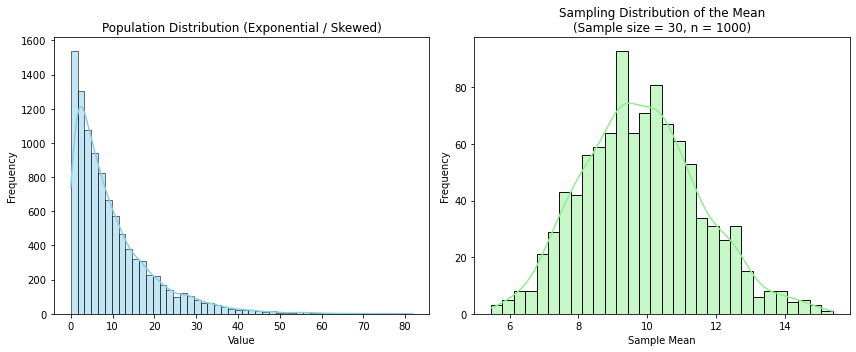

In [75]:
# Step 3: Plot population vs sample means
plt.figure(figsize=(12,5))

# Population distribution
plt.subplot(1, 2, 1)
sns.histplot(population, bins=50, kde=True, color='skyblue')
plt.title("Population Distribution (Exponential / Skewed)")
plt.xlabel("Value")
plt.ylabel("Frequency")

# Sampling distribution of the mean
plt.subplot(1, 2, 2)
sns.histplot(sample_means, bins=30, kde=True, color='lightgreen')
plt.title(f"Sampling Distribution of the Mean\n(Sample size = {sample_size}, n = {num_samples})")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

- Left plot → The original population (skewed to the right).
- Right plot → The distribution of sample means (looks bell-shaped / Normal). 🎯 This is the Central Limit Theorem in action:
- No matter the shape of the population, the distribution of sample means tends toward Normal as the sample size increases.